# Feature Selection: SelectKBest + ANOVA (f_classif)

This notebook is a **first-pass feature selection baseline** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains a baseline model
- applies `SelectKBest(f_classif)`
- retrains and compares performance
- visualizes top ANOVA feature scores
- saves selected feature names and transformed datasets

**Default dataset key for this notebook:** `tfidf`


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')

Imports loaded.


## 2) Configuration

Pick which extracted feature table to run.

Recommended first run: `mfcc_raw` (fast and stable).

In [ ]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()

FEATURE_SOURCES = {
    'mfcc_raw': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features.csv',
    'mfcc_normalized': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features_normalized.csv',
    'prosody_energy': REPO_ROOT / 'extracted_features' / 'prosody_energy' / 'prosody_energy_features.csv',
    'bert': REPO_ROOT / 'extracted_features' / 'text' / 'bert_embeddings.csv',
    'tfidf': REPO_ROOT / 'extracted_features' / 'text' / 'tfidf_features.csv',
    'prosody_pitch': REPO_ROOT / 'extracted_features' / 'prosody_pitch' / 'prosody_pitch_features.csv'
}

DATASET_KEY = 'tfidf'   
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
K_FEATURES = 300           # can be int or 'all';
USE_NROWS = None           # set e.g. 5000 for quick smoke runs on huge CSVs

METADATA_CANDIDATES = {
    'path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement',
    'utt_id', 'text', 'split'
}

source_path = FEATURE_SOURCES[DATASET_KEY]
print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())


Repository root: F:\Speech-Emotion-Recognition
Selected source: F:\Speech-Emotion-Recognition\extracted_features\text\tfidf_features.csv
Source exists: True


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

Data shape: (7532, 9165)
Metadata columns (10): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement', 'utt_id', 'text', 'split']
Feature columns (9155).
Sample feature columns: ['tfidf_00000', 'tfidf_00001', 'tfidf_00002', 'tfidf_00003', 'tfidf_00004', 'tfidf_00005', 'tfidf_00006', 'tfidf_00007', 'tfidf_00008', 'tfidf_00009']
Class distribution:
emotion
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
oth       3
dis       2
Name: count, dtype: int64


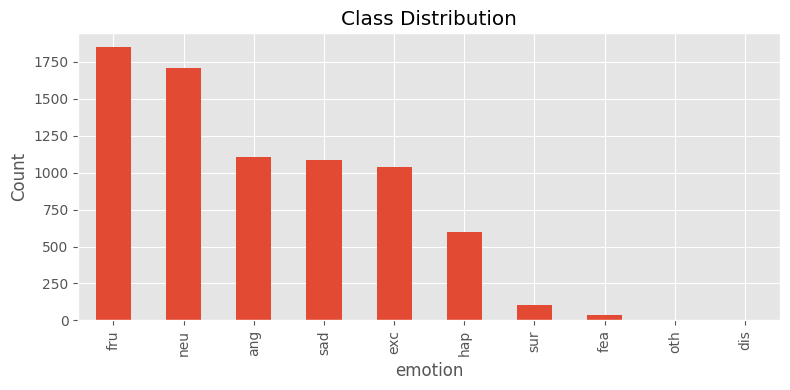

In [3]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(df.columns[:20])}...")

meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

print(f'Data shape: {df.shape}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

# quick class balance view
class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [4]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL])
model_df = model_df.dropna(axis=0, how='any')
rows_after = len(model_df)

X = model_df[feature_cols].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {list(label_enc.classes_)}')

Rows before cleaning: 7532
Rows after cleaning:  7532
Dropped rows:         0
Train shape: (6025, 9155)
Test shape:  (1507, 9155)
Classes: ['ang', 'dis', 'exc', 'fea', 'fru', 'hap', 'neu', 'oth', 'sad', 'sur']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

Baseline metrics:
Accuracy:      0.4924
Weighted F1:   0.4954
Classification report:
              precision    recall  f1-score   support

         ang       0.56      0.62      0.59       221
         dis       0.00      0.00      0.00         0
         exc       0.55      0.47      0.51       208
         fea       0.28      0.62      0.38         8
         fru       0.53      0.48      0.50       370
         hap       0.36      0.39      0.37       119
         neu       0.48      0.45      0.46       342
         oth       0.00      0.00      0.00         1
         sad       0.53      0.54      0.53       217
         sur       0.14      0.38      0.21        21

    accuracy                           0.49      1507
   macro avg       0.34      0.40      0.36      1507
weighted avg       0.50      0.49      0.50      1507



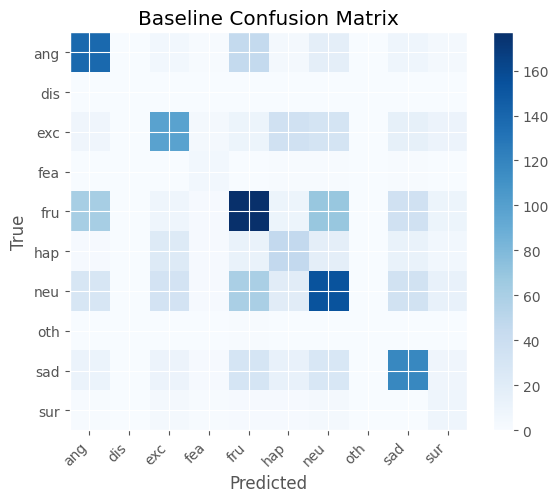

In [5]:
baseline_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

baseline_clf.fit(X_train, y_train)
base_pred = baseline_clf.predict(X_test)

base_acc = accuracy_score(y_test, base_pred)
base_f1 = f1_score(y_test, base_pred, average='weighted')

print('Baseline metrics:')
print(f'Accuracy:      {base_acc:.4f}')
print(f'Weighted F1:   {base_f1:.4f}')
print('Classification report:')
all_labels = np.arange(len(label_enc.classes_))
print(classification_report(y_test, base_pred, labels=all_labels, target_names=label_enc.classes_, zero_division=0))

cm = confusion_matrix(y_test, base_pred, labels=all_labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_title('Baseline Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(range(len(label_enc.classes_)))
ax.set_yticks(range(len(label_enc.classes_)))
ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
ax.set_yticklabels(label_enc.classes_)
plt.tight_layout()
plt.show()

## 6) SelectKBest (ANOVA F-test)

`f_classif` ranks each feature independently by class separability.

F:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  21   34   87  311  428  498  584  679  733  761  820  871  881  986
  989 1089 1221 1343 1517 1605 1712 1847 1954 2333 2511 2528 2570 2579
 2668 2759 2985 3065 3134 3187 3213 3342 3476 3540 3687 3748 3928 3962
 4090 4189 4214 4282 4434 4443 4598 4608 4609 4712 4808 4848 4970 5008
 5367 5408 5421 6002 6084 6113 6144 6152 6169 6225 6226 6231 6311 6318
 6319 6320 6419 6427 6478 6480 6485 6574 6667 6759 6831 6910 6969 7079
 7107 7181 7284 7325 7467 7471 7723 7742 7914 7994 7996 8020 8032 8076
 8176 8256 8312 8469 8492 8545 8610 8612 8615 8650 8662 8683 8736 8939
 8973 9027] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
F:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Original feature count: 9155
Selected feature count: 300
First 15 selected features:
 - tfidf_00015
 - tfidf_00066
 - tfidf_00076
 - tfidf_00167
 - tfidf_00189
 - tfidf_00220
 - tfidf_00342
 - tfidf_00473
 - tfidf_00478
 - tfidf_00494
 - tfidf_00496
 - tfidf_00529
 - tfidf_00535
 - tfidf_00538
 - tfidf_00543
Top 10 ANOVA-ranked features:
       feature  anova_f_score
0  tfidf_01759     668.111480
1  tfidf_01168     668.111480
2  tfidf_07978     259.976910
3  tfidf_03931     238.838971
4  tfidf_01317     238.838971
5  tfidf_02763     229.378651
6  tfidf_07358     229.378651
7  tfidf_02764     229.378651
8  tfidf_04979     216.276737
9  tfidf_03487     174.955638


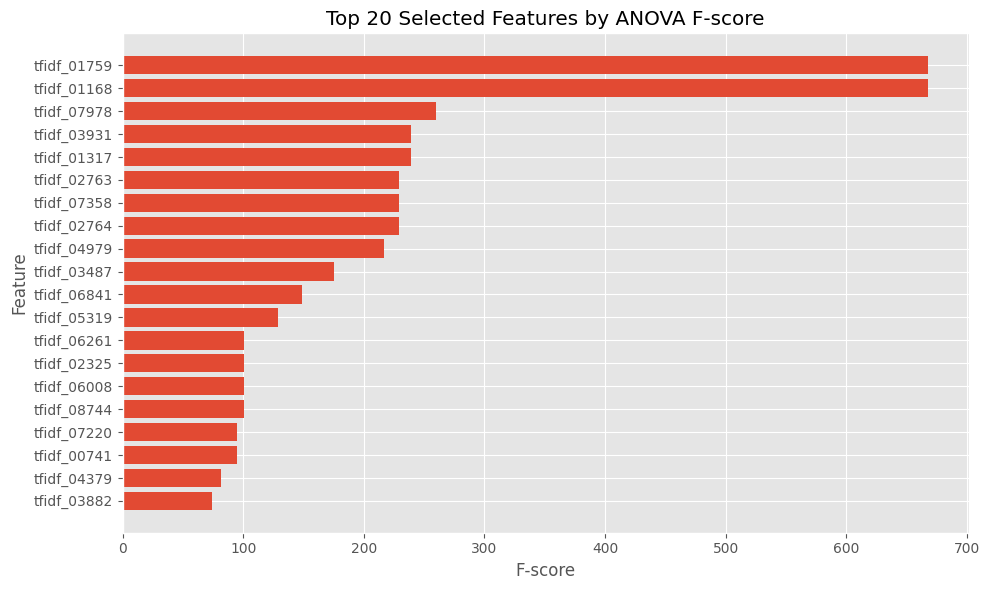

In [6]:
if K_FEATURES == 'all':
    k = 'all'
else:
    k = min(int(K_FEATURES), X_train.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

mask = selector.get_support()
selected_features = [col for col, keep in zip(feature_cols, mask) if keep]
selected_scores = selector.scores_[mask]

print(f'Original feature count: {X_train.shape[1]}')
print(f'Selected feature count: {len(selected_features)}')
print('First 15 selected features:')
for name in selected_features[:15]:
    print(' -', name)

# Top ANOVA scores
rank_df = pd.DataFrame({
    'feature': selected_features,
    'anova_f_score': selected_scores,
}).sort_values('anova_f_score', ascending=False, ignore_index=True)

print('Top 10 ANOVA-ranked features:')
print(rank_df.head(10))

plot_n = min(20, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank_df.head(plot_n)['feature'][::-1], rank_df.head(plot_n)['anova_f_score'][::-1])
ax.set_title(f'Top {plot_n} Selected Features by ANOVA F-score')
ax.set_xlabel('F-score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 7) Model After Selection

Train the same classifier, now only on selected features.

In [7]:
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

selected_clf.fit(X_train_sel, y_train)
sel_pred = selected_clf.predict(X_test_sel)

sel_acc = accuracy_score(y_test, sel_pred)
sel_f1 = f1_score(y_test, sel_pred, average='weighted')

print('Post-selection metrics:')
print(f'Accuracy:      {sel_acc:.4f}')
print(f'Weighted F1:   {sel_f1:.4f}')
print('Classification report:')
all_labels = np.arange(len(label_enc.classes_))
print(classification_report(y_test, sel_pred, labels=all_labels, target_names=label_enc.classes_, zero_division=0))

print('\nMetric delta (selected - baseline):')
print(f'Accuracy delta:    {sel_acc - base_acc:+.4f}')
print(f'Weighted F1 delta: {sel_f1 - base_f1:+.4f}')

Post-selection metrics:
Accuracy:      0.3796
Weighted F1:   0.3824
Classification report:
              precision    recall  f1-score   support

         ang       0.40      0.44      0.42       221
         dis       0.00      0.00      0.00         0
         exc       0.40      0.31      0.35       208
         fea       0.44      0.50      0.47         8
         fru       0.48      0.32      0.39       370
         hap       0.27      0.29      0.28       119
         neu       0.35      0.44      0.39       342
         oth       0.00      0.00      0.00         1
         sad       0.43      0.43      0.43       217
         sur       0.12      0.43      0.19        21

    accuracy                           0.38      1507
   macro avg       0.29      0.32      0.29      1507
weighted avg       0.40      0.38      0.38      1507


Metric delta (selected - baseline):
Accuracy delta:    -0.1128
Weighted F1 delta: -0.1129


## 8) Save Artifacts

This exports selected feature names, scores, and transformed train/test matrices.

In [8]:
out_dir = REPO_ROOT / 'feature_selection' / 'filter' / 'select_k_best_anova' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_selected_features.json'
rank_path = out_dir / f'{DATASET_KEY}_anova_ranking.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_selected.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_selected.csv'
meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

with selected_feature_path.open('w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)

rank_df.to_csv(rank_path, index=False)

X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
X_train_sel_df.to_csv(train_sel_path, index=False)
X_test_sel_df.to_csv(test_sel_path, index=False)

run_meta = {
    'dataset_key': DATASET_KEY,
    'source_path': str(source_path),
    'target_col': TARGET_COL,
    'rows_used': int(len(model_df)),
    'original_features': int(X_train.shape[1]),
    'selected_features': int(len(selected_features)),
    'k_config': K_FEATURES,
    'k_effective': len(selected_features),
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'baseline_accuracy': float(base_acc),
    'baseline_f1_weighted': float(base_f1),
    'selected_accuracy': float(sel_acc),
    'selected_f1_weighted': float(sel_f1),
}

with meta_path.open('w', encoding='utf-8') as f:
    json.dump(run_meta, f, indent=2)

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)

Saved artifacts:
- F:\Speech-Emotion-Recognition\feature_selection\filter\select_k_best_anova\artifacts\tfidf_selected_features.json
- F:\Speech-Emotion-Recognition\feature_selection\filter\select_k_best_anova\artifacts\tfidf_anova_ranking.csv
- F:\Speech-Emotion-Recognition\feature_selection\filter\select_k_best_anova\artifacts\tfidf_X_train_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\filter\select_k_best_anova\artifacts\tfidf_X_test_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\filter\select_k_best_anova\artifacts\tfidf_run_metadata.json


## 9) Notes for Next Methods

After this baseline, common next folders/methods:
- `wrapper/rfe_logreg/`
- `embedded/l1_logreg/`
- `embedded/tree_importance/`
- `dimensionality/pca/`